This project aims to predict the **maximum temperature for the next day (Next_Tmax)** using meteorological features derived from the 'Bias Correction of Numerical Prediction Model Temperature Forecast' dataset.

In [1]:
import pandas as pd

In [2]:
df_reg = pd.read_csv("Bias_correction_ucl.csv")
df_reg.head()


,station,Date,Present_Tmax,Present_Tmin,LDAPS_RHmin,LDAPS_RHmax,LDAPS_Tmax_lapse,LDAPS_Tmin_lapse,LDAPS_WS,LDAPS_LH,...,LDAPS_PPT2,LDAPS_PPT3,LDAPS_PPT4,lat,lon,DEM,Slope,Solar radiation,Next_Tmax,Next_Tmin
0,1.0,2013-06-30,28.7,21.4,58.255688,91.116364,28.074101,23.006936,6.818887,69.451805,...,0.0,0.0,0.0,37.6046,126.991,212.3350,2.7850,5992.895996,29.1,21.2
1,2.0,2013-06-30,31.9,21.6,52.263397,90.604721,29.850689,24.035009,5.691890,51.937448,...,0.0,0.0,0.0,37.6046,127.032,44.7624,0.5141,5869.312500,30.5,22.5
2,3.0,2013-06-30,31.6,23.3,48.690479,83.973587,30.091292,24.565633,6.138224,20.573050,...,0.0,0.0,0.0,37.5776,127.058,33.3068,0.2661,5863.555664,31.1,23.9
3,4.0,2013-06-30,32.0,23.4,58.239788,96.483688,29.704629,23.326177,5.650050,65.727144,...,0.0,0.0,0.0,37.6450,127.022,45.7160,2.5348,5856.964844,31.7,24.3
4,5.0,2013-06-30,31.4,21.9,56.174095,90.155128,29.113934,23.486480,5.735004,107.965535,...,0.0,0.0,0.0,37.5507,127.135,35.0380,0.5055,5859.552246,31.2,22.5


**Next_Tmax** and **Next_Tmin**: Target variables.

* Features include present temperatures (Present_Tmax, Present_Tmin), lapse rates, and atmospheric variables such as cloud cover, radiation, slope, etc.

* Goal: Compare different regression models and determine which performs best.


In [3]:
print(df_reg.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7752 entries, 0 to 7751
Data columns (total 25 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   station           7750 non-null   float64
 1   Date              7750 non-null   object 
 2   Present_Tmax      7682 non-null   float64
 3   Present_Tmin      7682 non-null   float64
 4   LDAPS_RHmin       7677 non-null   float64
 5   LDAPS_RHmax       7677 non-null   float64
 6   LDAPS_Tmax_lapse  7677 non-null   float64
 7   LDAPS_Tmin_lapse  7677 non-null   float64
 8   LDAPS_WS          7677 non-null   float64
 9   LDAPS_LH          7677 non-null   float64
 10  LDAPS_CC1         7677 non-null   float64
 11  LDAPS_CC2         7677 non-null   float64
 12  LDAPS_CC3         7677 non-null   float64
 13  LDAPS_CC4         7677 non-null   float64
 14  LDAPS_PPT1        7677 non-null   float64
 15  LDAPS_PPT2        7677 non-null   float64
 16  LDAPS_PPT3        7677 non-null   float64


In [4]:
df_reg.describe()

,station,Present_Tmax,Present_Tmin,LDAPS_RHmin,LDAPS_RHmax,LDAPS_Tmax_lapse,LDAPS_Tmin_lapse,LDAPS_WS,LDAPS_LH,LDAPS_CC1,...,LDAPS_PPT2,LDAPS_PPT3,LDAPS_PPT4,lat,lon,DEM,Slope,Solar radiation,Next_Tmax,Next_Tmin
count,7750.000000,7682.000000,7682.000000,7677.000000,7677.000000,7677.000000,7677.000000,7677.000000,7677.000000,7677.000000,...,7677.000000,7677.000000,7677.000000,7752.000000,7752.000000,7752.000000,7752.000000,7752.000000,7725.000000,7725.000000
mean,13.000000,29.768211,23.225059,56.759372,88.374804,29.613447,23.512589,7.097875,62.505019,0.368774,...,0.485003,0.278200,0.269407,37.544722,126.991397,61.867972,1.257048,5341.502803,30.274887,22.932220
std,7.211568,2.969999,2.413961,14.668111,7.192004,2.947191,2.345347,2.183836,33.730589,0.262458,...,1.762807,1.161809,1.206214,0.050352,0.079435,54.279780,1.370444,429.158867,3.128010,2.487613
min,1.000000,20.000000,11.300000,19.794666,58.936283,17.624954,14.272646,2.882580,-13.603212,0.000000,...,0.000000,0.000000,0.000000,37.456200,126.826000,12.370000,0.098475,4329.520508,17.400000,11.300000
25%,7.000000,27.800000,21.700000,45.963543,84.222862,27.673499,22.089739,5.678705,37.266753,0.146654,...,0.000000,0.000000,0.000000,37.510200,126.937000,28.700000,0.271300,4999.018555,28.200000,21.300000
50%,13.000000,29.900000,23.400000,55.039024,89.793480,29.703426,23.760199,6.547470,56.865482,0.315697,...,0.000000,0.000000,0.000000,37.550700,126.995000,45.716000,0.618000,5436.345215,30.500000,23.100000
75%,19.000000,32.000000,24.900000,67.190056,93.743629,31.710450,25.152909,8.032276,84.223616,0.575489,...,0.018364,0.007896,0.000041,37.577600,127.042000,59.832400,1.767800,5728.316406,32.600000,24.600000
max,25.000000,37.600000,29.900000,98.524734,100.000153,38.542255,29.619342,21.857621,213.414006,0.967277,...,21.621661,15.841235,16.655469,37.645000,127.135000,212.335000,5.178230,5992.895996,38.900000,29.800000


In [5]:
df_reg.isnull().sum()
df_reg = df_reg.dropna(subset=['Next_Tmax', 'Next_Tmin'])
df_reg['Next_Tmax'] = df_reg['Next_Tmax'].fillna(df_reg['Next_Tmax'].mean())
df_reg['Next_Tmin'] = df_reg['Next_Tmin'].fillna(df_reg['Next_Tmin'].mean())


* The dataset contains 24 features with 7752 entries. 

* We check for missing values and descriptive statistics to understand the feature distribution.

In [6]:
print(df_reg.dtypes)


station             float64
Date                 object
Present_Tmax        float64
Present_Tmin        float64
LDAPS_RHmin         float64
LDAPS_RHmax         float64
LDAPS_Tmax_lapse    float64
LDAPS_Tmin_lapse    float64
LDAPS_WS            float64
LDAPS_LH            float64
LDAPS_CC1           float64
LDAPS_CC2           float64
LDAPS_CC3           float64
LDAPS_CC4           float64
LDAPS_PPT1          float64
LDAPS_PPT2          float64
LDAPS_PPT3          float64
LDAPS_PPT4          float64
lat                 float64
lon                 float64
DEM                 float64
Slope               float64
Solar radiation     float64
Next_Tmax           float64
Next_Tmin           float64
dtype: object


In [7]:
df_reg = df_reg.drop(columns=['Date'])


In [8]:
from sklearn.impute import KNNImputer
imputer = KNNImputer(n_neighbors=5)
df_reg.iloc[:, :] = imputer.fit_transform(df_reg)


In [9]:
print(df_reg.columns)


Index(['station', 'Present_Tmax', 'Present_Tmin', 'LDAPS_RHmin', 'LDAPS_RHmax',
       'LDAPS_Tmax_lapse', 'LDAPS_Tmin_lapse', 'LDAPS_WS', 'LDAPS_LH',
       'LDAPS_CC1', 'LDAPS_CC2', 'LDAPS_CC3', 'LDAPS_CC4', 'LDAPS_PPT1',
       'LDAPS_PPT2', 'LDAPS_PPT3', 'LDAPS_PPT4', 'lat', 'lon', 'DEM', 'Slope',
       'Solar radiation', 'Next_Tmax', 'Next_Tmin'],
      dtype='object')


In [10]:
# Handle missing values (fill missing feature values with mean)
df_reg = df_reg.fillna(df_reg.mean())

# Define input features (X) and targets (y)
X = df_reg.drop(columns=['Next_Tmax', 'Next_Tmin'])
y_Tmax = df_reg['Next_Tmax']
y_Tmin = df_reg['Next_Tmin']

# Standardize the features
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split the data into train and test sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train_Tmax, y_test_Tmax = train_test_split(X_scaled, y_Tmax, test_size=0.2, random_state=42)
X_train, X_test, y_train_Tmin, y_test_Tmin = train_test_split(X_scaled, y_Tmin, test_size=0.2, random_state=42)



* Dropped irrelevant columns like Date since temporal information was not necessary.
* Imputed missing values for Next_Tmax and Next_Tmin with mean values.
* Scaled features using StandardScaler to standardize input for regression models.

In [11]:
df_reg.head()

,station,Present_Tmax,Present_Tmin,LDAPS_RHmin,LDAPS_RHmax,LDAPS_Tmax_lapse,LDAPS_Tmin_lapse,LDAPS_WS,LDAPS_LH,LDAPS_CC1,...,LDAPS_PPT2,LDAPS_PPT3,LDAPS_PPT4,lat,lon,DEM,Slope,Solar radiation,Next_Tmax,Next_Tmin
0,1.0,28.7,21.4,58.255688,91.116364,28.074101,23.006936,6.818887,69.451805,0.233947,...,0.0,0.0,0.0,37.6046,126.991,212.3350,2.7850,5992.895996,29.1,21.2
1,2.0,31.9,21.6,52.263397,90.604721,29.850689,24.035009,5.691890,51.937448,0.225508,...,0.0,0.0,0.0,37.6046,127.032,44.7624,0.5141,5869.312500,30.5,22.5
2,3.0,31.6,23.3,48.690479,83.973587,30.091292,24.565633,6.138224,20.573050,0.209344,...,0.0,0.0,0.0,37.5776,127.058,33.3068,0.2661,5863.555664,31.1,23.9
3,4.0,32.0,23.4,58.239788,96.483688,29.704629,23.326177,5.650050,65.727144,0.216372,...,0.0,0.0,0.0,37.6450,127.022,45.7160,2.5348,5856.964844,31.7,24.3
4,5.0,31.4,21.9,56.174095,90.155128,29.113934,23.486480,5.735004,107.965535,0.151407,...,0.0,0.0,0.0,37.5507,127.135,35.0380,0.5055,5859.552246,31.2,22.5


* Our goal is to train and evaluate four models **(Linear Regression, Ridge Regression, Decision Tree, Random Forest)**

* We find the MSE (Mean Squared Error) and R² score

In [12]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Fit Linear Regression model for Next_Tmax
lr_model = LinearRegression()
lr_model.fit(X_train, y_train_Tmax)

# Predict and evaluate
y_pred_Tmax = lr_model.predict(X_test)
print("MSE for Next_Tmax (Linear Regression):", mean_squared_error(y_test_Tmax, y_pred_Tmax))
print("R² for Next_Tmax (Linear Regression):", r2_score(y_test_Tmax, y_pred_Tmax))


MSE for Next_Tmax (Linear Regression): 2.056827420607521
R² for Next_Tmax (Linear Regression): 0.7838139701362679


In [13]:
from sklearn.linear_model import Ridge, Lasso

# Ridge Regression
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train_Tmax)
y_pred_ridge = ridge.predict(X_test)
print("MSE for Next_Tmax (Ridge):", mean_squared_error(y_test_Tmax, y_pred_ridge))
print("R² for Next_Tmax (Ridge):", r2_score(y_test_Tmax, y_pred_ridge))


MSE for Next_Tmax (Ridge): 2.0567629413572055
R² for Next_Tmax (Ridge): 0.7838207473276815


In [14]:
from sklearn.tree import DecisionTreeRegressor

tree = DecisionTreeRegressor(max_depth=5, random_state=42)
tree.fit(X_train, y_train_Tmax)
y_pred_tree = tree.predict(X_test)
print("MSE for Next_Tmax (Decision Tree):", mean_squared_error(y_test_Tmax, y_pred_tree))
print("R² for Next_Tmax (Decision Tree):", r2_score(y_test_Tmax, y_pred_tree))


MSE for Next_Tmax (Decision Tree): 2.345023079634342
R² for Next_Tmax (Decision Tree): 0.7535227192881205


In [15]:
from sklearn.model_selection import GridSearchCV

# Example: Tuning Ridge Regression
param_grid = {'alpha': [0.1, 1.0, 10.0]}
grid_search = GridSearchCV(Ridge(), param_grid, cv=5, scoring='neg_mean_squared_error')
grid_search.fit(X_train, y_train_Tmax)
print("Best parameters:", grid_search.best_params_)
best_ridge = grid_search.best_estimator_


Best parameters: {'alpha': 10.0}


In [25]:
from sklearn.ensemble import RandomForestRegressor

forest = RandomForestRegressor(n_estimators=100, random_state=42)
forest.fit(X_train, y_train_Tmax)
y_pred_forest = forest.predict(X_test)
print("MSE for Next_Tmax (Random Forest):", mean_squared_error(y_test_Tmax, y_pred_forest))
print("R² for Next_Tmax (Random Forest):", r2_score(y_test_Tmax, y_pred_forest))


MSE for Next_Tmax (Random Forest): 1.0050450032362455
R² for Next_Tmax (Random Forest): 0.8943631891975413


In [26]:
df_reg.columns

Index(['station', 'Present_Tmax', 'Present_Tmin', 'LDAPS_RHmin', 'LDAPS_RHmax',
       'LDAPS_Tmax_lapse', 'LDAPS_Tmin_lapse', 'LDAPS_WS', 'LDAPS_LH',
       'LDAPS_CC1', 'LDAPS_CC2', 'LDAPS_CC3', 'LDAPS_CC4', 'LDAPS_PPT1',
       'LDAPS_PPT2', 'LDAPS_PPT3', 'LDAPS_PPT4', 'lat', 'lon', 'DEM', 'Slope',
       'Solar radiation', 'Next_Tmax', 'Next_Tmin'],
      dtype='object')

In [27]:
df_reg.dtypes

station             float64
Present_Tmax        float64
Present_Tmin        float64
LDAPS_RHmin         float64
LDAPS_RHmax         float64
LDAPS_Tmax_lapse    float64
LDAPS_Tmin_lapse    float64
LDAPS_WS            float64
LDAPS_LH            float64
LDAPS_CC1           float64
LDAPS_CC2           float64
LDAPS_CC3           float64
LDAPS_CC4           float64
LDAPS_PPT1          float64
LDAPS_PPT2          float64
LDAPS_PPT3          float64
LDAPS_PPT4          float64
lat                 float64
lon                 float64
DEM                 float64
Slope               float64
Solar radiation     float64
Next_Tmax           float64
Next_Tmin           float64
dtype: object

In [28]:
X_train_full = X_train
y_train_full = y_train_Tmax

# Train a simple Random Forest Regressor
from sklearn.ensemble import RandomForestRegressor

forest = RandomForestRegressor(
    n_estimators=100,  # Match previous number of estimators
    max_depth=None,  # Default value for no limit on tree depth
    random_state=42  # Keep results reproducible
)
forest.fit(X_train_full, y_train_full)

# Evaluate feature importance
feature_importance = forest.feature_importances_

In [29]:
print("Best parameters:", grid_search.best_params_)

# Retrieve the best estimator (model with optimal parameters)
best_rf = grid_search.best_estimator_


Best parameters: {'alpha': 10.0}


In [21]:
from sklearn.metrics import mean_squared_error, r2_score

# Predict on the test set
y_pred_best = best_rf.predict(X_test)

# Calculate metrics
mse = mean_squared_error(y_test_Tmax, y_pred_best)
r2 = r2_score(y_test_Tmax, y_pred_best)

# Print evaluation metrics
print("Best Model MSE:", mse)
print("Best Model R²:", r2)


Best Model MSE: 2.0562677390374766
Best Model R²: 0.7838727963340342


In [22]:
feature_names = df_reg.drop(columns=['Next_Tmax', 'Next_Tmin']).columns


             Feature  Importance
20             Slope    0.003156
17               lat    0.003901
16        LDAPS_PPT4    0.004418
19               DEM    0.004998
18               lon    0.005477
15        LDAPS_PPT3    0.006089
13        LDAPS_PPT1    0.006989
0            station    0.007017
14        LDAPS_PPT2    0.008863
4        LDAPS_RHmax    0.011225
8           LDAPS_LH    0.013084
3        LDAPS_RHmin    0.013189
10         LDAPS_CC2    0.014254
6   LDAPS_Tmin_lapse    0.016233
2       Present_Tmin    0.016245
21   Solar radiation    0.018979
7           LDAPS_WS    0.021789
12         LDAPS_CC4    0.023094
11         LDAPS_CC3    0.024491
9          LDAPS_CC1    0.030202
1       Present_Tmax    0.057640
5   LDAPS_Tmax_lapse    0.688668


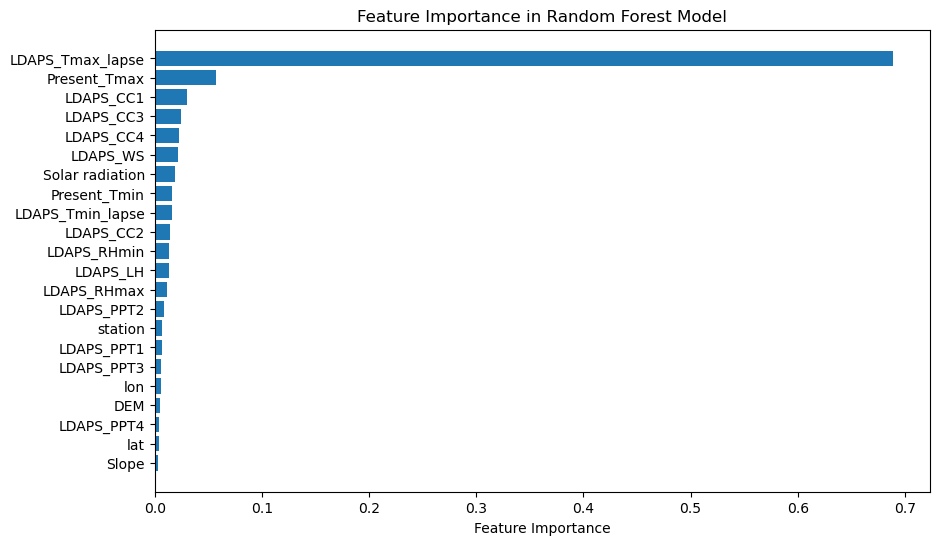

In [23]:
import matplotlib.pyplot as plt
import pandas as pd

#DataFrame for feature importance
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importance
}).sort_values(by='Importance', ascending=True)

print(feature_importance_df)

# Plot feature importance
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'])
plt.xlabel("Feature Importance")
plt.title("Feature Importance in Random Forest Model")
plt.show()

The most important features for predicting Next_Tmax are atmospheric and temperature-related:

* LDAPS_Tmax_lapse (temperature change over time),
* Present_Tmax (current day's maximum temperature),
* Cloud cover variables (LDAPS_CC1, LDAPS_CC2, LDAPS_CC3, LDAPS_CC4),
* Solar radiation.

With **LDAPS_Tmax_lapse being the absolute highest**, this feature is the most important in predicting Next_Tmax, with an importance score of 0.6802. This indicates that the change or variation in temperature (Tmax_lapse) is a key factor influencing the next day's maximum temperature forecast. It likely captures temperature fluctuations over time, which are critical in weather forecasting.

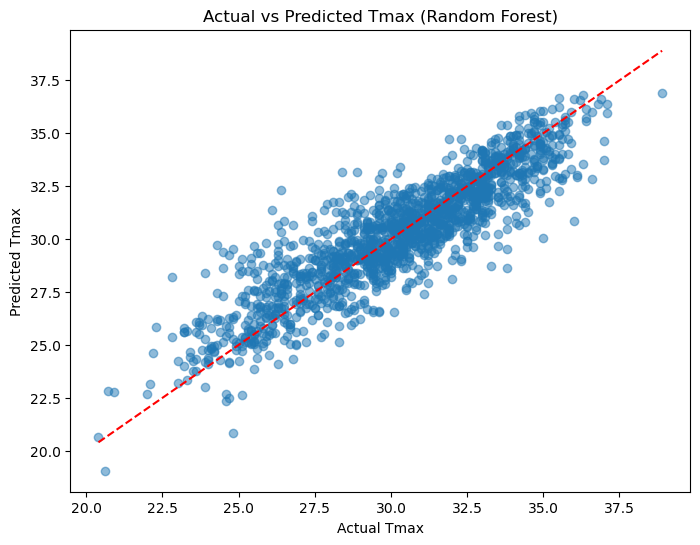

In [24]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 6))
plt.scatter(y_test_Tmax, y_pred_best, alpha=0.5)
plt.plot([y_test_Tmax.min(), y_test_Tmax.max()], [y_test_Tmax.min(), y_test_Tmax.max()], 'r--')  # Perfect prediction line
plt.xlabel("Actual Tmax")
plt.ylabel("Predicted Tmax")
plt.title("Actual vs Predicted Tmax (Random Forest)")
plt.show()


The scatterplot generated illustrates the **Actual vs Predicted Tmax for the Random Forest model**. Here's an interpretation of the results:


* Each blue point represents a pair of the actual (y_test_Tmax) and predicted (y_pred_best) maximum temperatures.

* The points close to the diagonal red line indicate accurate predictions, as the actual and predicted values are nearly equal.

* The red dashed line is the "perfect prediction" line, where the actual values equal the predicted values. The closer the scatter points are to this line, the better the model's performance.

* Most points are clustered close to the red line, indicating that the model performs well in predicting Next_Tmax. The relatively tight spread suggests a strong correlation between the predicted and actual values, which aligns with your previously calculated high R² score (~0.89).

* In conclusion the model performs well, with predictions closely matching actual values for most of the test data. The tight clustering near the red line reflects the high accuracy of the Random Forest model.

* **Best model: Random Forest with an R² of 0.89 and an MSE of 1.005**

* **Key feature: LDAPS_Tmax_lapse as the most important predictor.**

* **Accurate weather forecasts can rely heavily on atmospheric lapse rates and cloud cover metrics.**